# EV Charging Dataset — Initial Exploration

This notebook explores the raw EV charging dataset used for the PowerGrid EV Analytics project.

In [2]:
import pandas as pd

In [3]:
excel_file = pd.ExcelFile("../data/raw/ev_charging_dataset.xlsx")
excel_file.sheet_names

['stations', 'chargers', 'sessions']

In [4]:
stations = pd.read_excel(
    "../data/raw/ev_charging_dataset.xlsx",
    sheet_name = "stations"
)
stations.head()

,station_id,station_name,region,activation_year,n_chargers
0,STN_001,EV FastCharge 1,North West,2022,4
1,STN_002,EV FastCharge 2,London,2022,5
2,STN_003,EV FastCharge 3,Midlands,2022,5
3,STN_004,EV FastCharge 4,North West,2022,8
4,STN_005,EV FastCharge 5,North West,2022,8


In [5]:
stations.shape

(33, 5)

In [6]:
stations.columns

Index(['station_id', 'station_name', 'region', 'activation_year',
       'n_chargers'],
      dtype='object')

In [7]:
stations.dtypes

station_id         object
station_name       object
region             object
activation_year     int64
n_chargers          int64
dtype: object

In [8]:
stations.isnull().sum()

station_id         0
station_name       0
region             0
activation_year    0
n_chargers         0
dtype: int64

In [9]:
stations.duplicated().sum()

np.int64(0)

In [10]:
stations["station_id"].nunique()

33

In [11]:
stations["region"].value_counts()

region
North West            7
London                5
Midlands              5
South East            4
South West            3
North East            3
Scotland              3
Yorkshire & Humber    2
Wales                 1
Name: count, dtype: int64

In [12]:
stations["n_chargers"].value_counts().sort_index()

n_chargers
4     9
5     6
6     4
7     3
8    11
Name: count, dtype: int64

In [13]:
stations["n_chargers"].sum()

np.int64(199)

In [14]:
stations.describe()

,activation_year,n_chargers
count,33.000000,33.000000
mean,2023.242424,6.030303
std,0.830298,1.667424
min,2022.000000,4.000000
25%,2023.000000,4.000000
50%,2023.000000,6.000000
75%,2024.000000,8.000000
max,2024.000000,8.000000


In [15]:
chargers = pd.read_excel(
    "../data/raw/ev_charging_dataset.xlsx",
    sheet_name="chargers"
)
chargers.head()

,charger_id,station_id,charger_type,max_power_kW,installation_date
0,STN_001_CH_01,STN_001,DC_50kW,50,2022-06-07
1,STN_001_CH_02,STN_001,DC_150kW,150,2022-12-22
2,STN_001_CH_03,STN_001,DC_150kW,150,2022-10-21
3,STN_001_CH_04,STN_001,DC_50kW,50,2022-12-08
4,STN_002_CH_01,STN_002,DC_50kW,50,2022-07-09


In [16]:
chargers.shape

(199, 5)

In [17]:
chargers.columns

Index(['charger_id', 'station_id', 'charger_type', 'max_power_kW',
       'installation_date'],
      dtype='object')

In [18]:
chargers.dtypes

charger_id                   object
station_id                   object
charger_type                 object
max_power_kW                  int64
installation_date    datetime64[ns]
dtype: object

In [19]:
chargers.isnull().sum()

charger_id           0
station_id           0
charger_type         0
max_power_kW         0
installation_date    0
dtype: int64

In [20]:
chargers.duplicated().sum()

np.int64(0)

In [21]:
chargers['charger_id'].nunique()

199

In [22]:
chargers['charger_type'].value_counts()

charger_type
DC_50kW     95
DC_150kW    69
DC_300kW    35
Name: count, dtype: int64

In [23]:
chargers["station_id"].nunique()

33

In [24]:
chargers["max_power_kW"].describe()

count    199.000000
mean     128.643216
std       91.196692
min       50.000000
25%       50.000000
50%      150.000000
75%      150.000000
max      300.000000
Name: max_power_kW, dtype: float64

In [25]:
charger_counts = chargers.groupby("station_id").size()
charger_counts

station_id
STN_001    4
STN_002    5
STN_003    5
STN_004    8
STN_005    8
STN_006    4
STN_007    4
STN_008    5
STN_009    8
STN_010    8
STN_011    8
STN_012    5
STN_013    8
STN_014    4
STN_015    7
STN_016    6
STN_017    5
STN_018    4
STN_019    7
STN_020    6
STN_021    8
STN_022    4
STN_023    8
STN_024    7
STN_025    8
STN_026    8
STN_027    8
STN_028    4
STN_029    5
STN_030    4
STN_031    4
STN_032    6
STN_033    6
dtype: int64

In [26]:
station_comparison = stations.set_index("station_id")["n_chargers"].compare(charger_counts)

In [27]:
sessions = pd.read_excel(
    "../data/raw/ev_charging_dataset.xlsx",
    sheet_name="sessions"
)
sessions.head()

,session_id,station_id,charger_id,charger_type,start_timestamp,end_timestamp,session_duration_minutes,energy_kwh,price_per_kwh,total_cost,payment_method,user_type,customer_id,station_region,year
0,S_00000001,STN_001,STN_001_CH_02,DC_150kW,2022-01-01 08:30:00,2022-01-01 08:56:00,26,56.9,0.47,26.74,app,fleet,CUST_00134,North West,2022
1,S_00000002,STN_001,STN_001_CH_02,DC_150kW,2022-01-01 09:20:00,2022-01-01 09:41:00,21,40.7,0.46,18.72,app,delivery,CUST_00195,North West,2022
2,S_00000003,STN_001,STN_001_CH_04,DC_50kW,2022-01-01 09:00:00,2022-01-01 09:48:00,48,30.9,0.47,14.52,rfid,public,CUST_01935,North West,2022
3,S_00000004,STN_001,STN_001_CH_01,DC_50kW,2022-01-01 23:20:00,2022-01-02 00:01:00,41,28.4,0.45,12.78,rfid,public,CUST_00036,North West,2022
4,S_00000005,STN_001,STN_001_CH_01,DC_50kW,2022-01-01 16:10:00,2022-01-01 17:00:00,50,31.7,0.56,17.75,rfid,taxi,CUST_00011,North West,2022


In [28]:
sessions.shape

(294024, 15)

In [29]:
sessions.dtypes

session_id                          object
station_id                          object
charger_id                          object
charger_type                        object
start_timestamp             datetime64[ns]
end_timestamp               datetime64[ns]
session_duration_minutes             int64
energy_kwh                         float64
price_per_kwh                      float64
total_cost                         float64
payment_method                      object
user_type                           object
customer_id                         object
station_region                      object
year                                 int64
dtype: object

In [30]:
sessions.isnull().sum()

session_id                  0
station_id                  0
charger_id                  0
charger_type                0
start_timestamp             0
end_timestamp               0
session_duration_minutes    0
energy_kwh                  0
price_per_kwh               0
total_cost                  0
payment_method              0
user_type                   0
customer_id                 0
station_region              0
year                        0
dtype: int64

In [31]:
sessions.duplicated().sum()

np.int64(0)

In [32]:
sessions["session_id"].nunique()

294024

In [33]:
missing_stations = ~sessions["station_id"].isin(stations["station_id"])

missing_stations.sum()

np.int64(0)

In [34]:
missing_chargers = ~sessions["charger_id"].isin(chargers["charger_id"])

missing_chargers.sum()

np.int64(0)

In [35]:
calculated_duration = (
    sessions["end_timestamp"] - sessions["start_timestamp"]
).dt.total_seconds() / 60

In [36]:
(sessions["session_duration_minutes"] != calculated_duration).sum()

np.int64(0)

In [37]:
calculated_cost = (
    sessions["energy_kwh"] * sessions["price_per_kwh"]
)

cost_difference = (
    calculated_cost - sessions["total_cost"]
).abs()

cost_difference.max()

0.005000000000002558

In [38]:
(sessions["session_duration_minutes"] <= 0).sum()

np.int64(0)

In [39]:
(sessions["energy_kwh"] <= 0).sum()

np.int64(0)

In [40]:
sessions_with_power = sessions.merge(
    chargers[["charger_id", "max_power_kW"]],
    on="charger_id",
    how="left"
)

In [41]:
sessions_with_power["max_possible_energy_kwh"] = (
    sessions_with_power["max_power_kW"]
    * sessions_with_power["session_duration_minutes"]
    / 60
)

In [42]:
(
    sessions_with_power["energy_kwh"]
    > sessions_with_power["max_possible_energy_kwh"]
).sum()

np.int64(0)

In [43]:
sessions["charger_type"].value_counts()

charger_type
DC_50kW     136821
DC_150kW     96977
DC_300kW     60226
Name: count, dtype: int64

In [44]:
sessions["payment_method"].value_counts()

payment_method
app     98267
rfid    97894
card    97863
Name: count, dtype: int64

In [45]:
sessions["user_type"].value_counts()

user_type
public      73754
fleet       73696
delivery    73339
taxi        73235
Name: count, dtype: int64

## Task 1 — EV Charging Demand Forecasting

In [46]:
daily_demand = (
    sessions
    .set_index("start_timestamp")
    .resample("D")["energy_kwh"]
    .sum()
    .reset_index()
)

In [47]:
daily_demand.head()

,start_timestamp,energy_kwh
0,2022-01-01,5024.4
1,2022-01-02,3861.3
2,2022-01-03,6250.3
3,2022-01-04,5620.4
4,2022-01-05,6104.1


In [48]:
daily_demand.shape

(1096, 2)

In [49]:
daily_demand.describe()

,start_timestamp,energy_kwh
count,1096,1096.000000
mean,2023-07-02 12:00:00,12599.220620
min,2022-01-01 00:00:00,3428.000000
25%,2022-10-01 18:00:00,6111.725000
50%,2023-07-02 12:00:00,11611.550000
75%,2024-04-01 06:00:00,17513.500000
max,2024-12-31 00:00:00,25668.700000
std,NaN,6778.440236


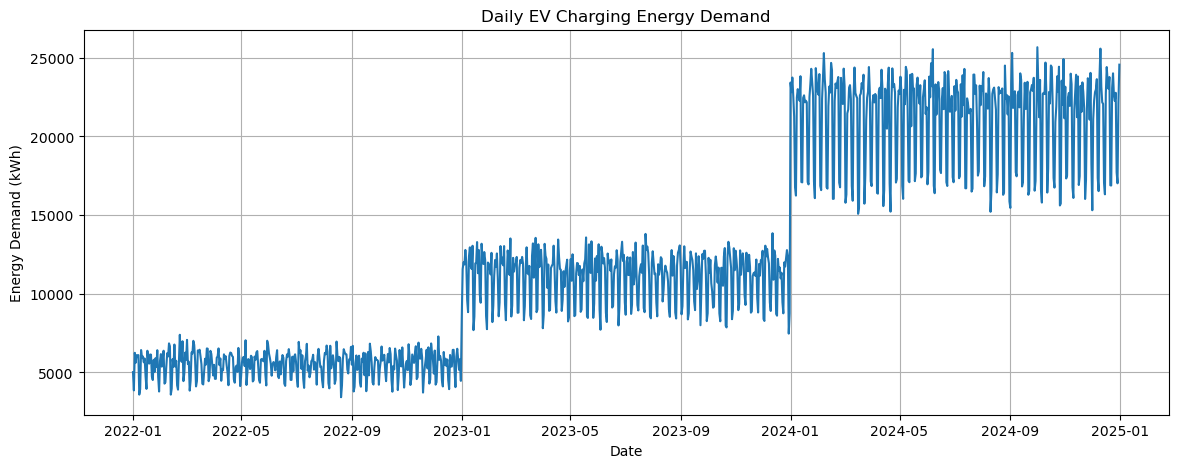

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(
    daily_demand['start_timestamp'],
    daily_demand['energy_kwh']
)

plt.title("Daily EV Charging Energy Demand")
plt.xlabel("Date")
plt.ylabel("Energy Demand (kWh)")
plt.grid(True)
plt.show()


In [54]:
daily_demand["day_of_week"] = daily_demand["start_timestamp"].dt.day_name()

weekly_pattern = (
    daily_demand
    .groupby("day_of_week")["energy_kwh"]
    .mean()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

weekly_pattern

day_of_week
Monday       13644.095541
Tuesday      13698.337580
Wednesday    13616.025000
Thursday     13602.746154
Friday       13692.376282
Saturday      9965.952229
Sunday        9994.842675
Name: energy_kwh, dtype: float64

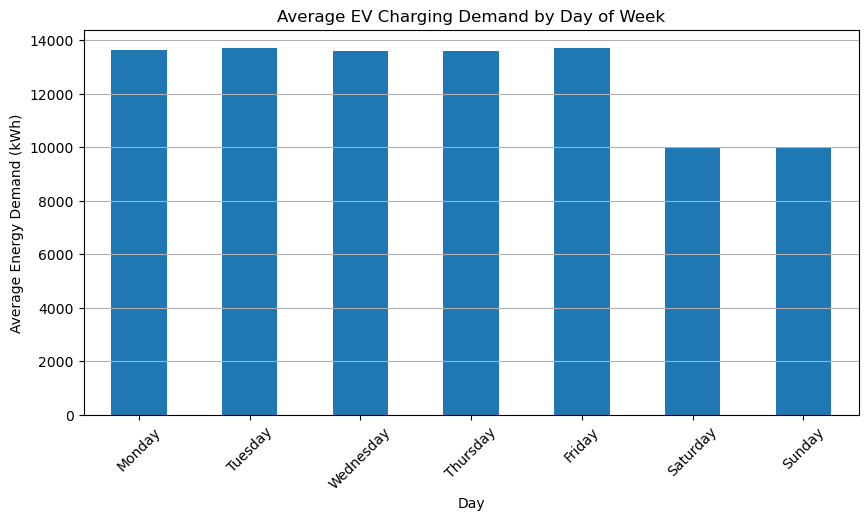

In [58]:
weekly_pattern.plot(kind='bar', figsize=(10,5))

plt.title("Average EV Charging Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Energy Demand (kWh)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [60]:
daily_demand = daily_demand.drop(columns='day_of_week')

In [61]:
daily_demand.head()

,start_timestamp,energy_kwh
0,2022-01-01,5024.4
1,2022-01-02,3861.3
2,2022-01-03,6250.3
3,2022-01-04,5620.4
4,2022-01-05,6104.1


In [62]:
#
train = daily_demand.iloc[:-90]
test = daily_demand.iloc[-90:]

print("Training:", train.shape)
print("Testing:", test.shape)
print("Training period:", train["start_timestamp"].min(), "to", train["start_timestamp"].max())
print("Testing period:", test["start_timestamp"].min(), "to", test["start_timestamp"].max())

Training: (1006, 2)
Testing: (90, 2)
Training period: 2022-01-01 00:00:00 to 2024-10-02 00:00:00
Testing period: 2024-10-03 00:00:00 to 2024-12-31 00:00:00


In [63]:
train_series = train.set_index("start_timestamp")["energy_kwh"]
test_series = test.set_index("start_timestamp")["energy_kwh"]

train_series.head()

start_timestamp
2022-01-01    5024.4
2022-01-02    3861.3
2022-01-03    6250.3
2022-01-04    5620.4
2022-01-05    6104.1
Name: energy_kwh, dtype: float64

In [64]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [65]:
sarima_model = SARIMAX(
    train_series,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)

print(sarima_result.summary())

C:\Users\Lenovo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Lenovo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                        energy_kwh   No. Observations:                 1006
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -8188.403
Date:                           Sat, 12 Sep 2026   AIC                          16386.805
Time:                                   22:57:28   BIC                          16411.289
Sample:                               01-01-2022   HQIC                         16396.115
                                    - 10-02-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1637      0.033      4.999      0.000       0.099       0.228
ma.L1         -0.6915      0.025    -27.328

In [66]:
sarima_forecast = sarima_result.get_forecast(steps=len(test))

sarima_pred = sarima_forecast.predicted_mean

sarima_pred.head()

2024-10-03    23415.483328
2024-10-04    23872.452411
2024-10-05    17395.734984
2024-10-06    17660.105806
2024-10-07    23371.061880
Freq: D, Name: predicted_mean, dtype: float64

In [67]:
len(sarima_pred)

90

In [68]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(test_series, sarima_pred)
)

mape = mean_absolute_percentage_error(
    test_series,
    sarima_pred
) * 100

print(f"SARIMA RMSE: {rmse:.2f} kWh")
print(f"SARIMA MAPE: {mape:.2f}%")

SARIMA RMSE: 1856.88 kWh
SARIMA MAPE: 7.95%
